![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/05/logo-upv-horizontal.png)
![PIC UPV PERTE Chip Chair Logo](https://www.pic-chair.upv.es/wp-content/uploads/2024/06/logos-perte-chip-1024x119.png)


# Laboratory 1. Waveguides

Welcome to our Photonic Integrated Circuits Laboratory! Throughout the course, we will be using a Python package called [GDSFactory](https://gdsfactory.github.io/gdsfactory/index.html). This is an open-source tool, and is a great alternative to other commercial software like Synopsys Optodesigner, Luceda Photonics, or Lumerical/Interconnect. Since it runs on Python, you have two options for executing your laboratory tasks:

1. **Local installation on your own PC** (Recommended): Please note that we will not spend class time on installing the software. However, feel free to reach out if you need help with the installation.

2. **Cloud Workspace**: Alternatively, you can use a cloud-based solution if the Local installation does not work.

## 0. Imports

For this laboratory you will need the following libraries:

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td

import gplugins as gp
import gplugins.tidy3d as gt
from gplugins import plot
from gplugins.common.config import PATH

nm = 1e-3
wavelength = np.linspace(1500, 1600,11) * nm
f = td.C_0 / wavelength


## LO.1. Effective index of a waveguide

### 1.1. Materials

We need the refractive index of each material in the cross-section. There are different options to get this information, such as [RefractiveIndex.info](https://refractiveindex.info/) and the [Material Library from Tidy3D](https://docs.flexcompute.com/projects/tidy3d/en/v2.6.0/api/material_library.html#). Here we will load and check the characteristics from the most common materials used in fabrication of photonic circuits: **silicon (Si), silicon nitride (SiNx) and silicon dioxide (SiO2)**.

#### 1.1.1. Crystalline Silicon 

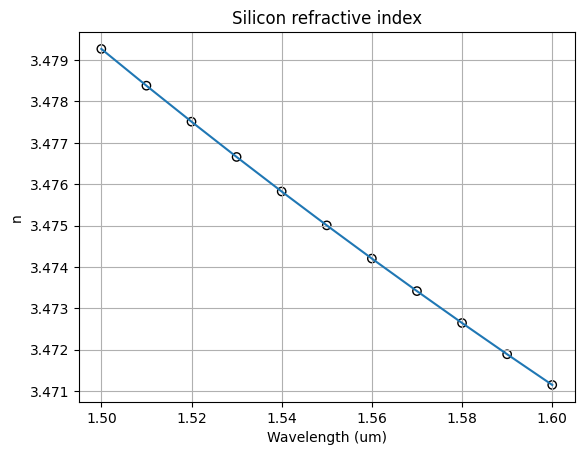

In [3]:
## Material model loaded
si_complex = td.material_library["cSi"]["Li1993_293K"].eps_model(f)
## Check the Tidy3D Docs for more information on the "Variant"

## Index at a particular wavelength
si_index , si_k = td.Medium.eps_complex_to_nk(si_complex)
plt.scatter(wavelength, si_index,edgecolors='k',facecolors='none')
plt.plot(wavelength,si_index)
plt.title("Silicon refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

#### 1.1.2. Silicon Nitride

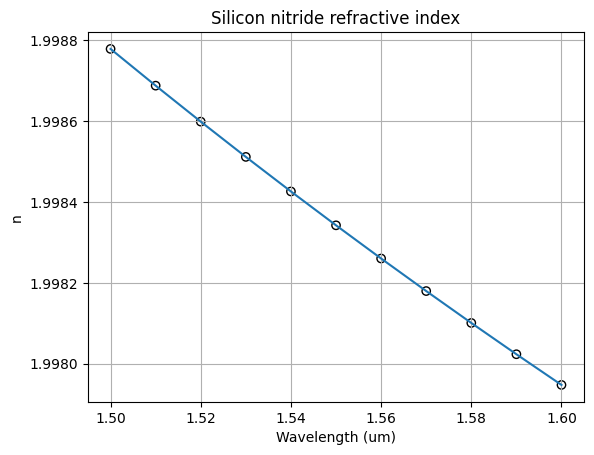

In [4]:
nitride_complex = td.material_library["Si3N4"]["Luke2015PMLStable"].eps_model(f)
nitride_index, nitride_k = td.Medium.eps_complex_to_nk(nitride_complex)
plt.scatter(wavelength,nitride_index,edgecolors='k',facecolors='none')
plt.plot(wavelength, nitride_index)
plt.title("Silicon nitride refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()


#### 1.1.3. Silicon Dioxide

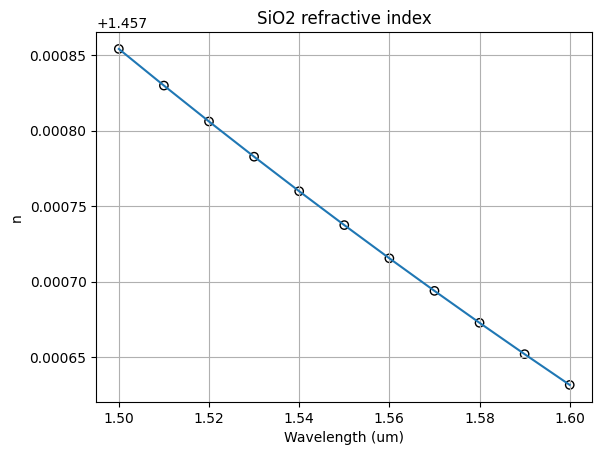

In [5]:
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.scatter(wavelength,box_index,edgecolors='k',facecolors='None')
plt.plot(wavelength, box_index)
plt.title("SiO2 refractive index")
plt.xlabel("Wavelength (um)")
plt.ylabel("n")
plt.grid()

### 1.2. Cross - Section Definition

In GDSFactory - Tidy3d modesolver we just have to use the [gt.modes.Waveguide()](https://gdsfactory.github.io/gplugins/_autosummary/gplugins.tidy3d.modes.Waveguide.html) function. 
It implements the **deep (rib)** and **shallow (ridge)** waveguide variants. The following example corresponds to a **deep** waveguide for the **silicon nitride** fabrication proccess, this means that the **cladding** material is silicon dioxide and the **core** material is silicon nitride. The waveguide dimensions are 300 nm (height) and 1.2 um (width). We will check it's behavior at 1.55 um. 

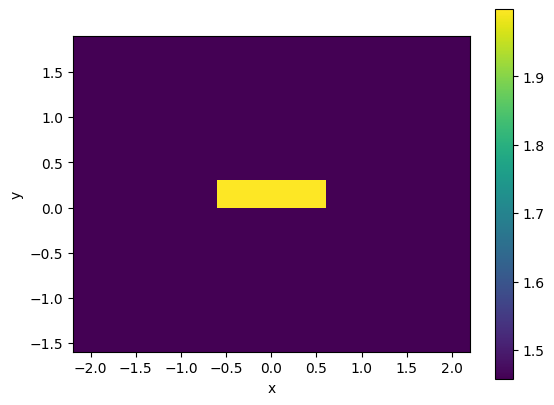

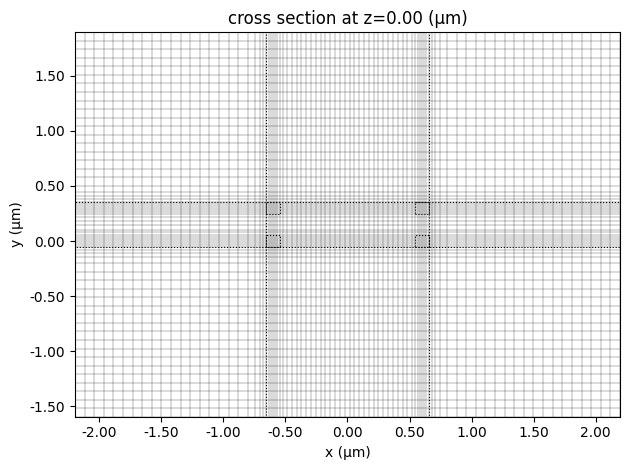

In [6]:
deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=1.2, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=1550 * nm, # Wavelength to simulate
    num_modes=4, # Targeted number of modes to find 
    max_grid_scaling=1.5, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

deep_waveguide.plot_index()
deep_waveguide.plot_grid()

### 1.3. Simulations

#### 1.3.1. Numerical results

We can find the effective index (n_eff), TE and TM fraction for each particular cross-section.

In [7]:
deep_waveguide.n_eff

2026-03-04 08:17:04.528 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_cf92515ae4232c65.npz.


array([1.60524792+0.00010066j, 1.52829803+0.00017753j,
       1.45072999+0.00019228j, 1.43325817+0.00021838j])

In [8]:
#te0,tm0,te1,tm1
#vistos los resultados anteriores solo se preopagn el modo de orden 0 y el de orden 1 (1.60 y 1.52 son mayores que 1.45)
deep_waveguide.fraction_te

array([0.99505426, 0.01004259, 0.96264794, 0.047651  ])

In [9]:
#dos modos te (0.995 y 0.962) y modos tm (0.01 y 0.04)
deep_waveguide.fraction_tm

array([0.00494574, 0.98995741, 0.03735206, 0.952349  ])

#### 1.3.4. Plots

Text(0.5, 1.0, 'Titulo')

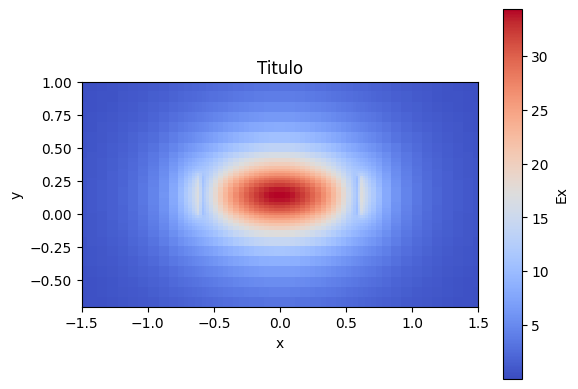

In [10]:
deep_waveguide.plot_field(mode_index=0 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # se puede poner o real - abs - imag
                            cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)
) # 
plt.title('Titulo') # You might need this later :) 
#en los modos TE siempre hay que buscar el campo TE en la direccion X. vemos que se concentra en el centro
#y por los bordes habra que hacer analisis de perdidas
#este es el modo TE0

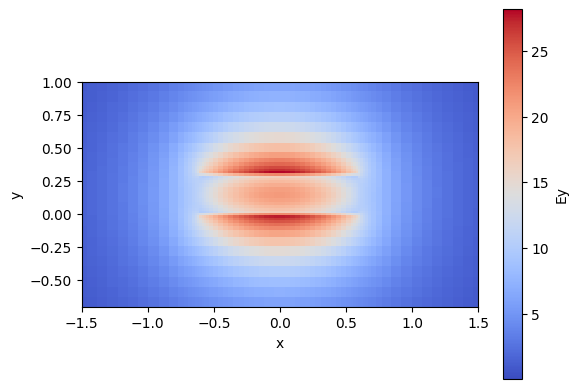

In [11]:
deep_waveguide.plot_field(mode_index=1 , # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
#si cuando se fabrica hay rugorsidad en la aprte superior e inferior se ve afectado el modo TM
#si cuando se fabrica hay rugosidad en la parte lateral se ve afectaado el modo TE
#esta grfica es el TM0

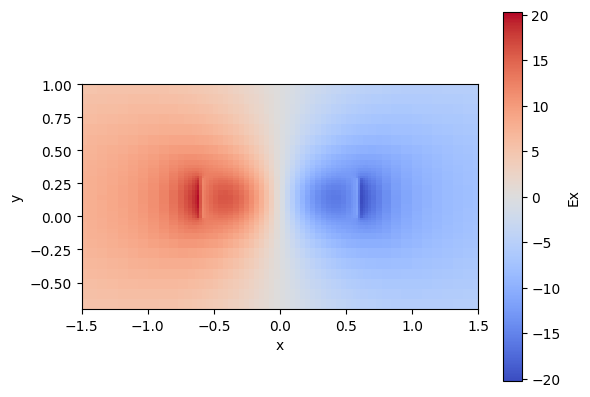

In [12]:
deep_waveguide.plot_field(mode_index=2 , # Mode to be plotted
                          field_name='Ex', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 
#este es el modo TE1 ya que solo tiene un corte en el centro, el numero de cortes indica el numero de modo

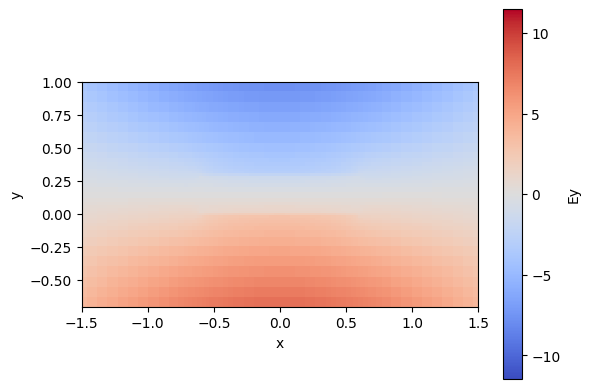

In [13]:
deep_waveguide.plot_field(mode_index=3, # Mode to be plotted
                          field_name='Ey', # Field to be plotted
                          value='real', # Real - abs - imag
                          cmap='coolwarm', # Suggestions: Change the plot color
                          xlim=(-1.5, 1.5), # Set the x and y limits
                          ylim=(-0.7, 1)) # 

**Important** 
These results are derived from a numerical method used to solve the EM problem, so they must always be interpreted carefully to assess their accuracy. You must check, for instance, if the value of each index neff is higher than the refractive index of the cladding. 

## LO.2. Wavelength behavior

- Let's find the wavelength dependence of the effective index of the SiNx deep waveguide described in LO1. Change the wavelength used at the waveguide cross-section function, it could be a vector also. 

2026-03-04 08:17:21.701 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ec785d26342315ad.npz.


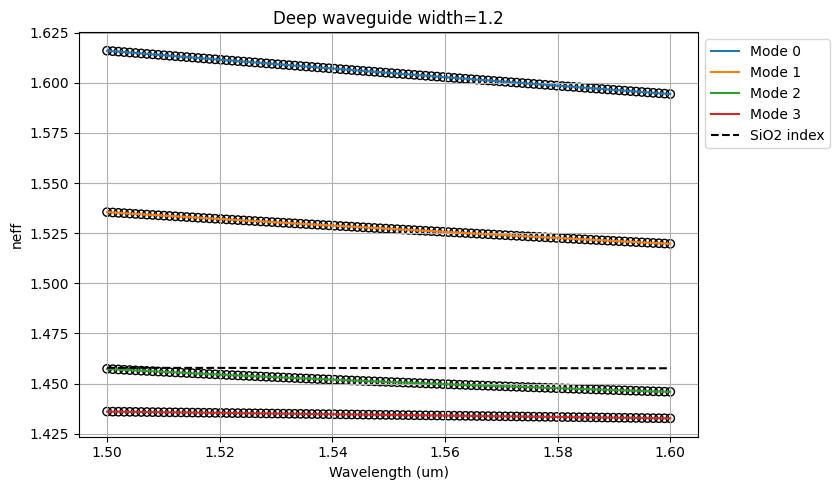

In [14]:
# The wavelength could be a vector also
#FOR DEEP WAVEGUIDE

wavelength =  np.linspace(1.5,1.6,100)# Student code here. Tip np.linspace()



deep_waveguide = gt.modes.Waveguide(
    
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)
f = td.C_0 / wavelength
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

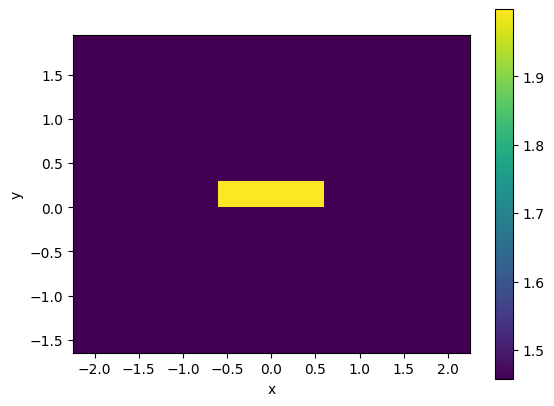

In [15]:
deep_waveguide.plot_index()

2026-03-04 08:17:28.392 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_54f93b93b7b96fc1.npz.


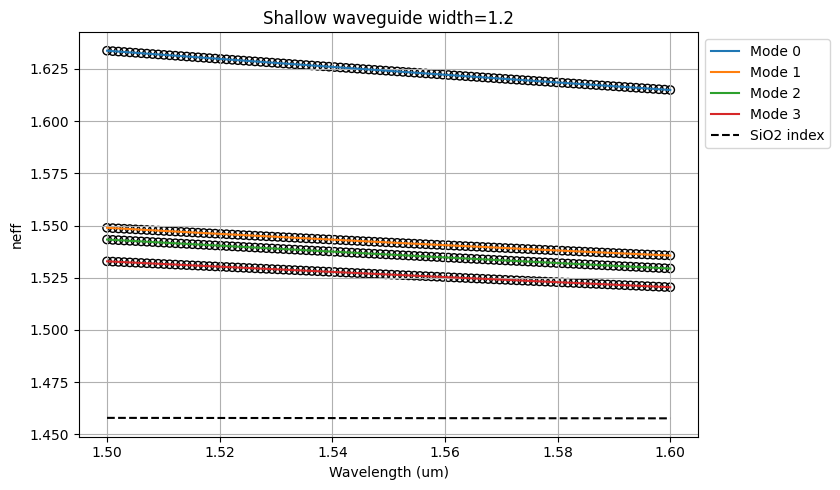

In [16]:
# The wavelength could be a vector also
#FOR SHALLOW WAVEGUIDE

wavelength =  np.linspace(1.5,1.6,100)# Student code here. Tip np.linspace()

deep_waveguide = gt.modes.Waveguide(
    
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=150*nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300*nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)
f = td.C_0 / wavelength
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

res_neff = deep_waveguide.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide.fraction_tm # Wavelength-dependent vector

plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Shallow waveguide width={1.2}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match 
# with the newly created wavelength vector, or re-calculate the box index for the new one. 
plt.plot(wavelength, box_index,'k--', label='SiO2 index') 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])


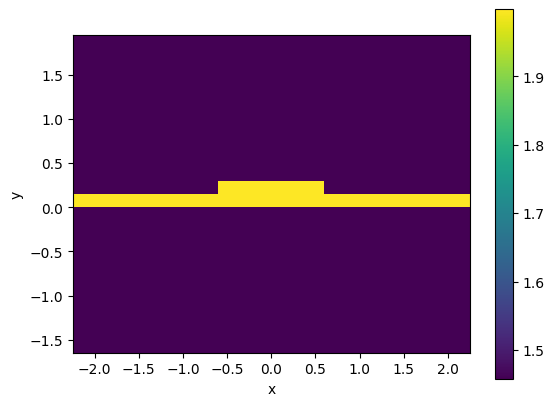

In [17]:
deep_waveguide.plot_index()

- Repeat the analysis for a **shallow**ly etched waveguide with a 150 nm slab heigth. 

## LO.3. Width dependence

- Perform a sweep of the **deep** waveguide width. Use the code provided in the following cell or program your own sweep. 

  0%|          | 0/100 [00:00<?, ?it/s]

2026-03-04 08:17:36.054 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-04 08:17:36.263 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e47f66408294b034.npz.
2026-03-04 08:17:36.685 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_03e13c7b22a79fc3.npz.
2026-03-04 08:17:36.969 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5a1ad9380a7cfe11.npz.
2026-03-04 08:17:37.145 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ca59e7429d26d4e9.npz.
2026-03-04 08:17:37.350 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_88654090b64b58de.npz.
2026-03-04 08:17:37.367 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7b3bc228dc9f5ad7.npz.
2026-03-04 08:17:37.372 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f354bf9c91a4853d.npz.


  0%|          | 0/100 [00:00<?, ?it/s]

2026-03-04 08:17:53.288 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e0f2a62752cad497.npz.
2026-03-04 08:17:53.294 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_e47f66408294b034.npz.
2026-03-04 08:17:53.298 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_03e13c7b22a79fc3.npz.
2026-03-04 08:17:53.303 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_5a1ad9380a7cfe11.npz.
2026-03-04 08:17:53.308 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ca59e7429d26d4e9.npz.
2026-03-04 08:17:53.314 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_88654090b64b58de.npz.
2026-03-04 08:17:53.320 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7b3bc228dc9f5ad7.npz.
2026-03-04 08:17:53.326 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f354bf9c91a4853d.npz.


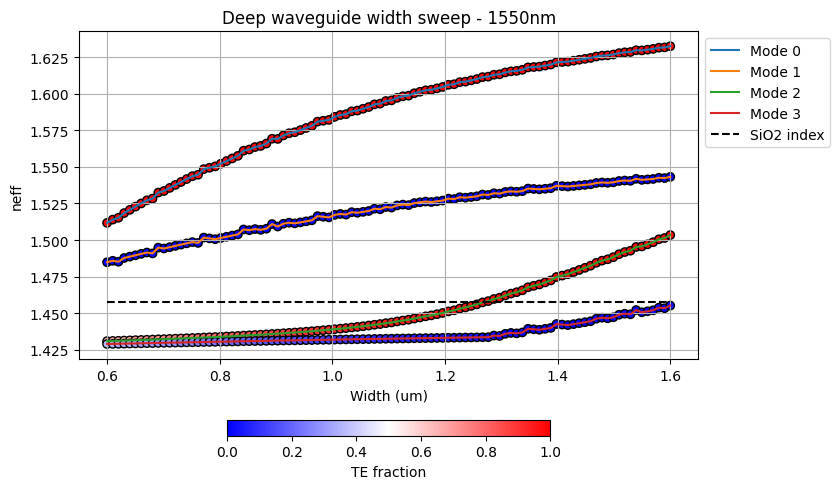

In [18]:
wavelength = 1.55 # Student code here

deep_waveguide = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=1.2,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)

w = np.linspace(0.6,1.6,100) # Student code here

sweep_neff = gt.modes.sweep_n_eff(deep_waveguide, 
                             core_width=w)

sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide,
                                              core_width=w)

plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')

plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

## LO.4. Waveguide compact model

A compact model of an integrated photonic waveguide is a reduced-order mathematical model that describes the waveguide’s optical behavior—such as phase propagation, loss, and dispersion, using analytical or semi-analytical equations. Consider: 

Consider: 

The transfer function for propagation in a waveguide:

$$
H(\lambda)
= e^{-j\,\gamma(\lambda)\,z}
= e^{-j\,\mathrm{Re}\{\gamma(\lambda)\}\,z}\,
  e^{\mathrm{Im}\{\gamma(\lambda)\}\,z}.
$$

Where 

$$
\beta(\lambda) = \mathrm{Re}\{\gamma(\lambda)\}\,z
= \frac{2\pi}{\lambda}\,n_\mathrm{eff}(\lambda).
$$

Let's model the waveguide's effective index wavelength variation using a second order polynomial:

$$
n_\mathrm{eff}(\lambda)
= n_{1} + n_{2}\,(\lambda-\lambda_{0}) + n_{3}\,(\lambda-\lambda_{0})^{2}
$$

Where 

1. 
$$
n_\mathrm{eff}(\lambda_0) = n_1
$$
2. 
$$
n_g(\lambda_0) = n_1 - n_2\,\lambda_0
$$
3. 
$$
D = -\frac{2\,\lambda_0\,n_3}{c}\;\;[\mathrm{s}^2/\mathrm{m}]
$$

- Find the values for n, ng and D of the following waveguides: 
    - Deep waveguide, height = 300nm, width = 1.2um 
    - Shallow waveguide, core height = 300nm, slab height = 150 nm, width = 1.2um 

**TIP**. Use the Lab0.1.Modesolver results (neff vs lambda) as starting point. Fit the results using a second order polynomial (with the lambda_0 shift) and relate the fit results to n_g and D values.

2026-02-28 13:19:20.973 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ec785d26342315ad.npz.



=== DEEP waveguide compact model (w=1.2um, h=300nm, slab=0) ===
TE0 (mode idx 0): n1=1.604917, n2=-2.161763e-01, n3=9.735802e-02, ng=1.939990, D=-1.006729e-09 [s/m^2]
TM0 (mode idx 1): n1=1.527189, n2=-1.579414e-01, n3=1.538322e-01, ng=1.771998, D=-1.590700e-09 [s/m^2]


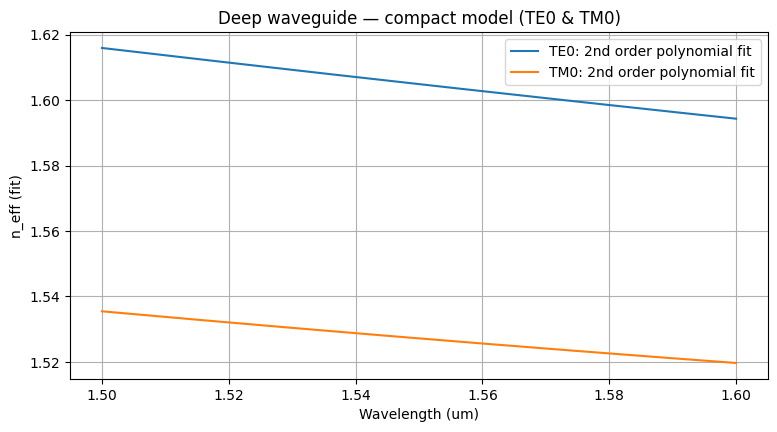

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
wavelength =  np.linspace(1.5,1.6,100)

deep_waveguide = gt.modes.Waveguide(
    
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)
f = td.C_0 / wavelength
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

res_neff = deep_waveguide.n_eff 
res_te = deep_waveguide.fraction_te 
res_tm =deep_waveguide.fraction_tm 

lambda0 = 1.55  # um
i0 = np.argmin(np.abs(wavelength - lambda0))

Nmodes = res_neff.shape[1]
Nlam = len(wavelength)

def pick_mode(frac_arr):
    frac_arr = np.array(frac_arr)
    if frac_arr.ndim == 2:              
        return int(np.argmax(frac_arr[i0, :]))
    if frac_arr.ndim == 1 and frac_arr.shape[0] == Nmodes:  
        return int(np.argmax(frac_arr))
    return 0  

idx_TE0 = 0  
idx_TM0 = 1  

neff_TE0 = res_neff[:, idx_TE0].real
neff_TM0 = res_neff[:, idx_TM0].real

def fit_poly2(neff_mode, wavelength_um, lambda0_um):
    dl = wavelength_um - lambda0_um
    n3, n2, n1 = np.polyfit(dl, neff_mode, 2)
    return n1, n2, n3

n1_te, n2_te, n3_te = fit_poly2(neff_TE0, wavelength, lambda0)
n1_tm, n2_tm, n3_tm = fit_poly2(neff_TM0, wavelength, lambda0)

c = td.C_0
lambda0_m = lambda0 * 1e-6

def calc_ng_D(lambda0_um, lambda0_m, n1, n2, n3):
    ng = n1 - lambda0_um * n2
    n3_m2 = n3 * 1e12  # 1/um^2 -> 1/m^2
    D = -(2 * lambda0_m * n3_m2) / c
    return ng, D

ng_te, D_te = calc_ng_D(lambda0, lambda0_m, n1_te, n2_te, n3_te)
ng_tm, D_tm = calc_ng_D(lambda0, lambda0_m, n1_tm, n2_tm, n3_tm)

print("\n=== DEEP waveguide compact model (w=1.2um, h=300nm, slab=0) ===")
print(f"TE0 (mode idx {idx_TE0}): n1={n1_te:.6f}, n2={n2_te:.6e}, n3={n3_te:.6e}, ng={ng_te:.6f}, D={D_te:.6e} [s/m^2]")
print(f"TM0 (mode idx {idx_TM0}): n1={n1_tm:.6f}, n2={n2_tm:.6e}, n3={n3_tm:.6e}, ng={ng_tm:.6f}, D={D_tm:.6e} [s/m^2]")

w_fine = np.linspace(wavelength.min(), wavelength.max(), 600)

def poly_eval(w, lambda0_um, n1, n2, n3):
    dl = w - lambda0_um
    return n1 + n2*dl + n3*dl**2

neff_te_fit = poly_eval(w_fine, lambda0, n1_te, n2_te, n3_te)
neff_tm_fit = poly_eval(w_fine, lambda0, n1_tm, n2_tm, n3_tm)

plt.figure(figsize=(9,4.5))
plt.plot(w_fine, neff_te_fit, label="TE0: 2nd order polynomial fit")
plt.plot(w_fine, neff_tm_fit, label="TM0: 2nd order polynomial fit")
plt.title("Deep waveguide — compact model (TE0 & TM0)")
plt.xlabel("Wavelength (um)")
plt.ylabel("n_eff (fit)")
plt.grid(True)
plt.legend()
plt.show()

2026-02-28 13:18:12.540 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_54f93b93b7b96fc1.npz.

=== SHALLOW waveguide compact model (w=1.2um, h=300nm, slab=0) ===
TE0 (mode idx 0): n1=1.624091, n2=-1.881714e-01, n3=9.569709e-02, ng=1.915756, D=-9.895545e-10 [s/m^2]
TM0 (mode idx 1): n1=1.541895, n2=-1.325376e-01, n3=1.479835e-01, ng=1.747329, D=-1.530221e-09 [s/m^2]


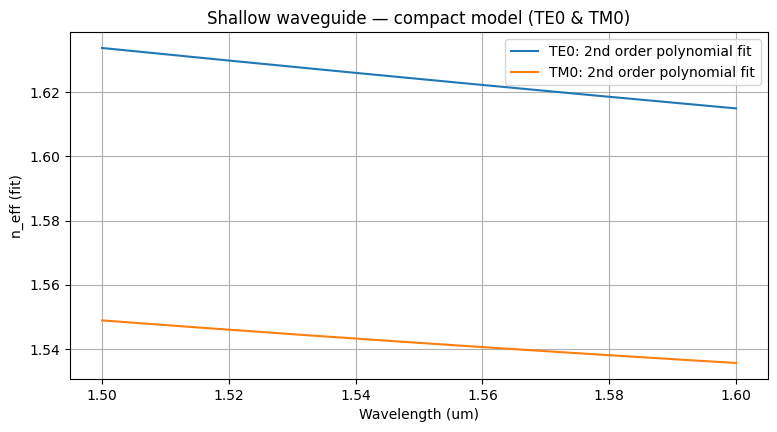

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
wavelength =  np.linspace(1.5,1.6,100)# Student code here. Tip np.linspace()

shallow_waveguide = gt.modes.Waveguide(
    
    wavelength=wavelength, 
    core_width=1.2, 
    slab_thickness=150*nm,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20, 
)
f = td.C_0 / wavelength
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)

res_neff = shallow_waveguide.n_eff
res_te = shallow_waveguide.fraction_te
res_tm =shallow_waveguide.fraction_tm 

lambda0 = 1.55  # um
i0 = np.argmin(np.abs(wavelength - lambda0))

Nmodes = res_neff.shape[1]
Nlam = len(wavelength)

def pick_mode(frac_arr):
    frac_arr = np.array(frac_arr)
    if frac_arr.ndim == 2:                # (Nlam, Nmodes)
        return int(np.argmax(frac_arr[i0, :]))
    if frac_arr.ndim == 1 and frac_arr.shape[0] == Nmodes:  # (Nmodes,)
        return int(np.argmax(frac_arr))
    return 0  

idx_TE0 = 0   # Mode 0 (línea azul arriba)
idx_TM0 = 1   # Mode 1 (línea amarilla arriba)

neff_TE0 = res_neff[:, idx_TE0].real
neff_TM0 = res_neff[:, idx_TM0].real

def fit_poly2(neff_mode, wavelength_um, lambda0_um):
    dl = wavelength_um - lambda0_um
    n3, n2, n1 = np.polyfit(dl, neff_mode, 2)
    return n1, n2, n3

n1_te, n2_te, n3_te = fit_poly2(neff_TE0, wavelength, lambda0)
n1_tm, n2_tm, n3_tm = fit_poly2(neff_TM0, wavelength, lambda0)

c = td.C_0
lambda0_m = lambda0 * 1e-6

def calc_ng_D(lambda0_um, lambda0_m, n1, n2, n3):
    ng = n1 - lambda0_um * n2
    n3_m2 = n3 * 1e12  # 1/um^2 -> 1/m^2
    D = -(2 * lambda0_m * n3_m2) / c
    return ng, D

ng_te, D_te = calc_ng_D(lambda0, lambda0_m, n1_te, n2_te, n3_te)
ng_tm, D_tm = calc_ng_D(lambda0, lambda0_m, n1_tm, n2_tm, n3_tm)

print("\n=== SHALLOW waveguide compact model (w=1.2um, h=300nm, slab=0) ===")
print(f"TE0 (mode idx {idx_TE0}): n1={n1_te:.6f}, n2={n2_te:.6e}, n3={n3_te:.6e}, ng={ng_te:.6f}, D={D_te:.6e} [s/m^2]")
print(f"TM0 (mode idx {idx_TM0}): n1={n1_tm:.6f}, n2={n2_tm:.6e}, n3={n3_tm:.6e}, ng={ng_tm:.6f}, D={D_tm:.6e} [s/m^2]")

w_fine = np.linspace(wavelength.min(), wavelength.max(), 600)

def poly_eval(w, lambda0_um, n1, n2, n3):
    dl = w - lambda0_um
    return n1 + n2*dl + n3*dl**2

neff_te_fit = poly_eval(w_fine, lambda0, n1_te, n2_te, n3_te)
neff_tm_fit = poly_eval(w_fine, lambda0, n1_tm, n2_tm, n3_tm)

plt.figure(figsize=(9,4.5))
plt.plot(w_fine, neff_te_fit, label="TE0: 2nd order polynomial fit")
plt.plot(w_fine, neff_tm_fit, label="TM0: 2nd order polynomial fit")
plt.title("Shallow waveguide — compact model (TE0 & TM0)")
plt.xlabel("Wavelength (um)")
plt.ylabel("n_eff (fit)")
plt.grid(True)
plt.legend()
plt.show()

#si no tengo variacion de longitud de onda con el indice efectivo, la linea es horizontal y el valor de ng es igual al valor de n1, y la dispersion es 0
#n2 es siempre negativo y n3 es siempre positivo, lo que indica que el indice efectivo decrece con la longitud de onda y que la dispersion es normal (D>0)
#cuanto mas difiera el ng que del neff es que mas variacion de longitud de onda 
#la dispersion es obligatoriamente negativa y nos dice que vamos a tener dispersion normal, que se ensancha en el dominio del tiempo. Si fuera D>0 se encogeria en el dominio del tiempo


## LO.5. Bend waveguide radius vs. loss – deep

The bend loss has three primary contributions:

1. Mode-mismatch loss
2. Radiation loss
3. Propagation loss

2026-03-04 09:30:42.988 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1592dba1d8e935a8.npz.


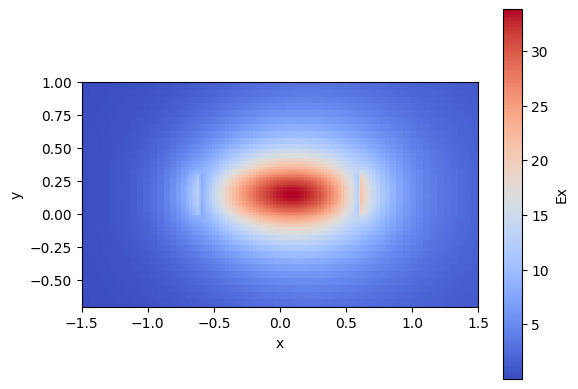

In [36]:
bend_1550 = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=1.2,
    slab_thickness=0.0,
    core_material='sin',
    clad_material='sio2',
    core_thickness=300 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=20, # Bend radius, el radio que se va cambiando
)

bend_1550.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='abs', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 



### Mode-mismatch loss

Bend waveguide mode differs slightly from the straight waveguide mode, wich yield into mode-convertion losses. We can calculate this factor with as the overlap of the latter two modes. 

This is already implemented on GDSfactory library: 

  0%|          | 0/6 [00:00<?, ?it/s]

/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

Text(0, 0.5, 'Mismatch (dB)')

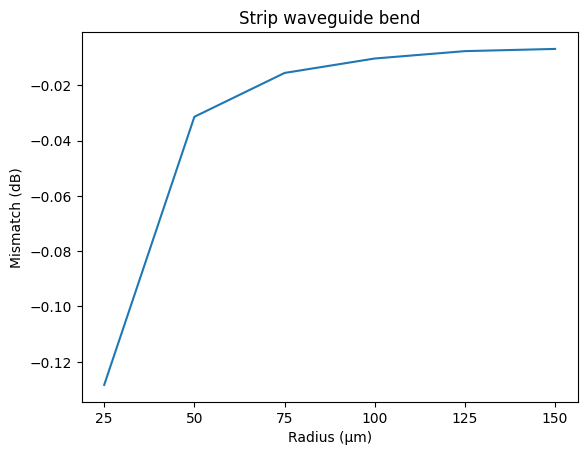

In [37]:
#radii = np.arange(20.0, 120,11)
radii = np.arange(25,175,25)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.xticks(radii)
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

### Propagation loss

Consider the equivalent linear length of the quarter-circle bend. Light will attenuate following a trend quantified with the experimentally measured parameter $$\alpha [\mathrm{dB}/\mathrm{cm}]$$. It depends on the fabrication process mainly. We will add this loss (in dBs) to the mode-mismatch loss to calculate the total loss per bend. 

*We are not considering the radiation losses, mainly because is not easy to implement a quick simulation for this parameter. Under certain conditions, the main loss sources are the ones considered in this example


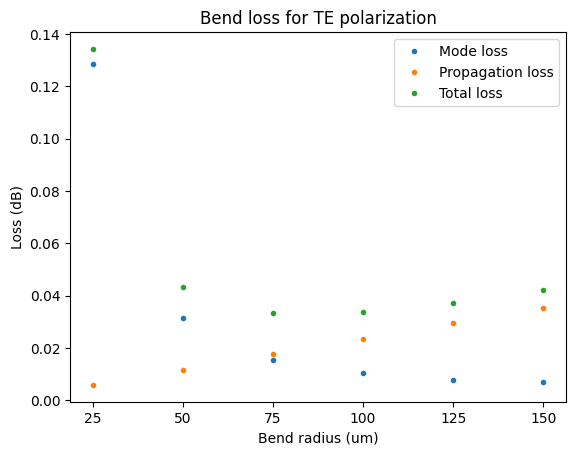

In [38]:
dB_cm = 1.5  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xticks(radii)
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

2026-03-04 09:31:39.266 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_13f241434025c7df.npz.
2026-03-04 09:31:39.270 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b6ff729f8004f9b5.npz.
2026-03-04 09:31:39.274 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7ea91cd9428d9d0a.npz.
2026-03-04 09:31:39.277 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1e54718f169a6068.npz.
2026-03-04 09:31:39.282 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c22cfd3c8a2199e6.npz.
2026-03-04 09:31:39.286 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_4e9c19381d587e62.npz.
R =  25 um  ->  neff_TE0 = 1.616192
R =  50 um  ->  neff_TE0 = 1.614638
R =  75 um  ->  neff_TE0 = 1.614402
R = 100 um  ->  neff_TE0 = 1.614335
R = 125 um  ->  neff_TE0 = 1.613930
R = 150 um  ->  neff_TE0 = 1.614301


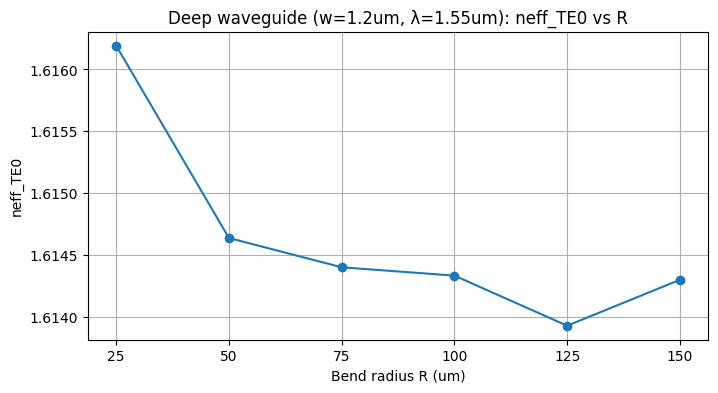

In [39]:
import numpy as np
import matplotlib.pyplot as plt

radii = np.array([25, 50, 75, 100, 125, 150])  # um
neff_TE0 = []

for R in radii:
    bend_1550 = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1.2,
        slab_thickness=0.0,       # DEEP
        core_material="sin",
        clad_material="sio2",
        core_thickness=300 * nm,
        num_modes=1,
        cache_path=".cache/",
        precision="double",
        max_grid_scaling=1.2,
        grid_resolution=30,
        bend_radius=R,            # um
    )

    # --- FIX: n_eff a veces es escalar ---
    n_eff_val = np.asarray(bend_1550.n_eff).real
    neff0 = float(n_eff_val[0]) if n_eff_val.ndim > 0 else float(n_eff_val)
    neff_TE0.append(neff0)

neff_TE0 = np.array(neff_TE0)

for R, n in zip(radii, neff_TE0):
    print(f"R = {R:>3} um  ->  neff_TE0 = {n:.6f}")

plt.figure(figsize=(8,4))
plt.plot(radii, neff_TE0, marker="o")
plt.xticks(radii)
plt.xlabel("Bend radius R (um)")
plt.ylabel("neff_TE0")
plt.title("Deep waveguide (w=1.2um, λ=1.55um): neff_TE0 vs R")
plt.grid(True)
plt.show()

In [ ]:
#el tercer ejericico extra es hacer esto otrea vez pero poneindo los parametros del primer ejericico camnnbaindo si0licon nitride por silicon, y cambiar e ancho y todo eso por los que nos dan en el ejercicio.

- Use the code provided in this section to calculate the safe radius for 1.2 um width deep waveguides at 1.5 um. Consider safe means less than 0.1 dB/90º

## EXTRA

All the past simulations were done considering as core material de Silicon Nitride (SiNx) and Silicon Dioxide (SiO2) as cladding material. Now, **simulate the Silicon-On-Insulator technology changing the core material to Silicon (Si)**. In this case, the dimensions will be 220 nm heigth and 500 nm width. 
1. Repeat the LO.2. wavelength behavior simulations, considering the updated materials and dimensions. 
2. Repeat the LO.3. width dependence analysis, now sweeping in a 300nm - 1um range. 
3. Find the safe radius for this technology. Consider sweeping the radius in a 5um to 30um range. 
4. **Compare the SiNx and SOI technologies** 

2026-03-11 16:28:53.215 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_63c0a620d6b7a025.npz.


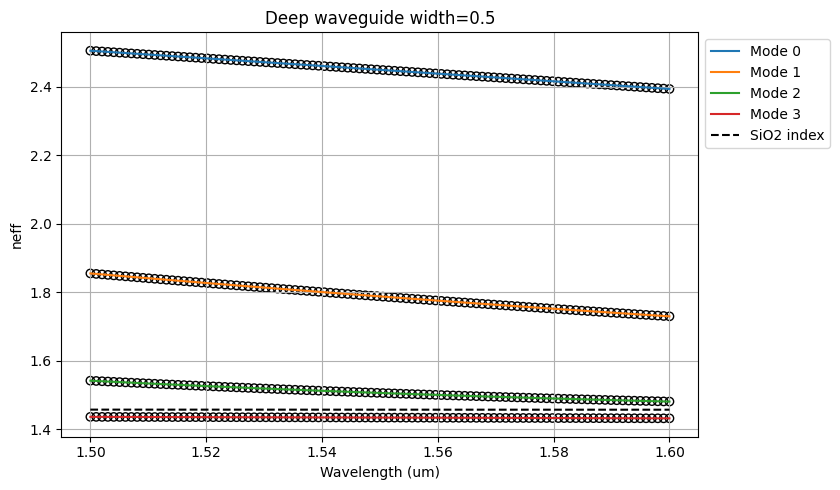

In [3]:
#ejercicio 1 extra
#Guia de silicio barrido wavelength para deep
wavelength = np.linspace(1.5, 1.6, 100) # Student code here. Tip np.linspace()
 
deep_waveguide_si = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=500 * nm,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)
 
res_neff = deep_waveguide_si.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = deep_waveguide_si.fraction_te # Wavelength-dependent vector
res_tm =deep_waveguide_si.fraction_tm # Wavelength-dependent vector
 
plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Deep waveguide width={0.5}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match
# with the newly created wavelength vector, or re-calculate the box index for the new one.
f = td.C_0 / wavelength
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.plot(wavelength, box_index,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

16:33:41 CET WARNING: Mode field at frequency index 0, mode index 1 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 2 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 0, mode index 3 does not    
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 1, mode index 1 does not    
             decay at the plane boundaries.                                     

...

             WARNING: Mode field at frequency index 98, mode index 3 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 99, mode index 1 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 99, mode index 2 does not   
             decay at the plane boundaries.                                     

             WARNING: Mode field at frequency index 99, mode index 3 does not   
             decay at the plane boundaries.                                     

2026-03-11 16:33:57.929 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_e8d91d8e0b55e0a6.npz.


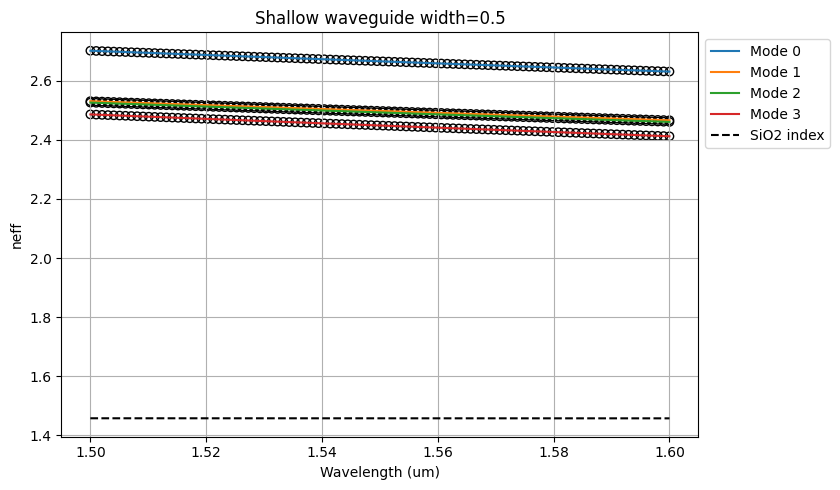

In [4]:
# Slab waveguide para el de silicio barrido wavelength
wavelength = np.linspace(1.5, 1.6, 100) # Student code here. Tip np.linspace()
 
slab_waveguide_si = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=500 * nm,
    slab_thickness=150 * nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)
 
res_neff = slab_waveguide_si.n_eff # In this case, the result is not just a number, is a wavelength-dependent vector
res_te = slab_waveguide_si.fraction_te # Wavelength-dependent vector
res_tm =slab_waveguide_si.fraction_tm # Wavelength-dependent vector
 
plt.figure(figsize=(10, 5))
for k in range(res_neff.shape[1]):
    # It's necessary to 'access' each element on the array
    plt.scatter(wavelength, res_neff[:,k].real,edgecolors='k',facecolors='none',label = '__nolegend__')
    plt.plot(wavelength, res_neff[:,k].real,label=f'Mode {k}')
plt.title(f"Shallow waveguide width={0.5}")
plt.xlabel("Wavelength (um)")
plt.ylabel("neff")
plt.grid()
# Common error: The box index variable was created in a previous cell. Check the dimensions match
# with the newly created wavelength vector, or re-calculate the box index for the new one.
f = td.C_0 / wavelength
box_complex = td.material_library["SiO2"]["Horiba"].eps_model(f)
box_index, box_k = td.Medium.eps_complex_to_nk(box_complex)
plt.plot(wavelength, box_index,'k--', label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])

  0%|          | 0/20 [00:00<?, ?it/s]

2026-03-11 17:05:10.186 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-11 17:05:10.194 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d11ff0c0ce944647.npz.
2026-03-11 17:05:10.199 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ac115ae7b6e8fb02.npz.
2026-03-11 17:05:10.219 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2d4bba79187bbdca.npz.
2026-03-11 17:05:10.223 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c341d5593b3daaa3.npz.
2026-03-11 17:05:10.230 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ca3a57dd470e2727.npz.
2026-03-11 17:05:10.234 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7af548af11e7ad74.npz.
2026-03-11 17:05:10.239 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f8c62088bd2f614e.npz.


/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-11 17:05:20.236 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_f9fc891ba094b195.npz.


/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

...

2026-03-11 17:05:37.806 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_a3182a0ad39330c5.npz.


/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-11 17:05:37.842 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_07b520dc17f68bb3.npz.


  0%|          | 0/20 [00:00<?, ?it/s]

2026-03-11 17:05:37.870 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_58b0951888c2c7de.npz.
2026-03-11 17:05:37.876 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_d11ff0c0ce944647.npz.
2026-03-11 17:05:37.882 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ac115ae7b6e8fb02.npz.
2026-03-11 17:05:37.885 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2d4bba79187bbdca.npz.
2026-03-11 17:05:37.889 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c341d5593b3daaa3.npz.
2026-03-11 17:05:37.894 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_ca3a57dd470e2727.npz.
2026-03-11 17:05:37.898 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7af548af11e7ad74.npz.
2026-03-11 17:05:37.904 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f8c62088bd2f614e.npz.


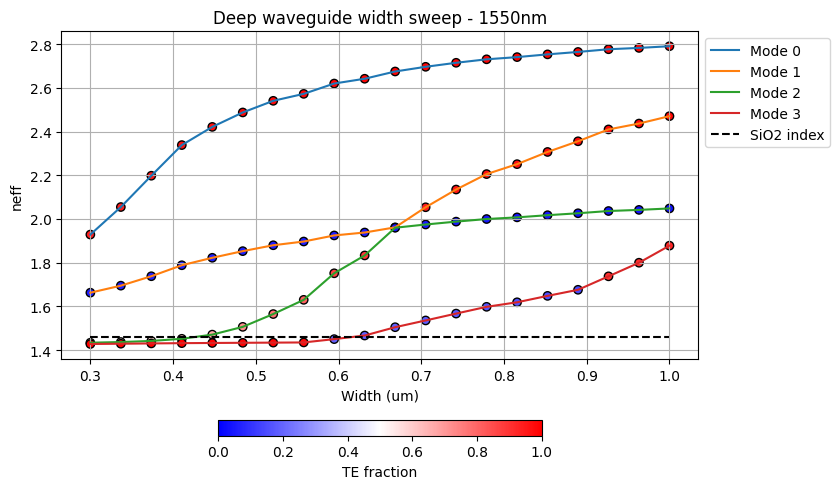

In [6]:
#ejercicio 2 extra
wavelength = 1.55 # Student code here
 
deep_waveguide_si = gt.modes.Waveguide(
    wavelength=wavelength,
    core_width=500 * nm,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    slab_thickness=0 * nm,
    num_modes=4,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=20,
)
 
w = np.linspace(0.3, 1, 20) # Student code here
 
sweep_neff = gt.modes.sweep_n_eff(deep_waveguide_si,
                             core_width=w)
 
sweep_tefraction = gt.modes.sweep_fraction_te(deep_waveguide_si,
                                              core_width=w)
 
plt.figure(figsize=(10, 5))
for k in range(sweep_neff.shape[1]):
    plt.scatter(w, sweep_neff[:,k].real,edgecolors='k',c=sweep_tefraction.sel(mode_index=k),vmin=0, vmax=1,label = '__nolegend__',cmap='bwr')
    plt.plot(w, sweep_neff[:,k].real,label=f'Mode {k}')
 
plt.title("Deep waveguide width sweep - 1550nm")
plt.xlabel("Width (um)")
plt.ylabel("neff")
plt.grid()
plt.hlines(np.mean(box_index), xmin=np.min(w), xmax=np.max(w), colors='k', linestyles='dashed',label='SiO2 index')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.colorbar(orientation='horizontal',fraction=0.04).set_label("TE fraction")

/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-04 09:49:01.756 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_1d0f5b8b6ea39532.npz.


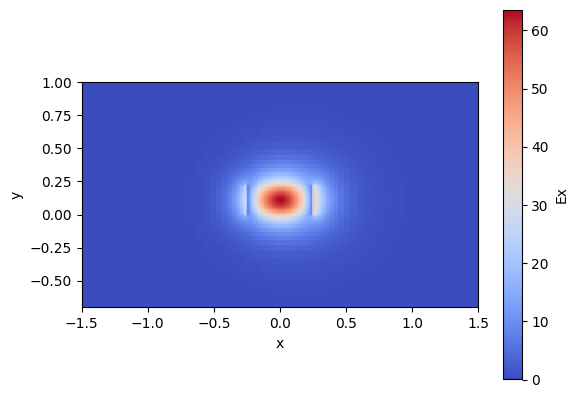

In [47]:
#ejercicio 3 extra
bend_1550_si = gt.modes.Waveguide(
    wavelength=1550 * nm,
    core_width=0.5,
    slab_thickness=0.0,
    core_material='si',
    clad_material='sio2',
    core_thickness=220 * nm,
    num_modes=1,
    cache_path='.cache/',
    precision='double',
    max_grid_scaling=1.2,
    grid_resolution=30, 
    bend_radius=3, # Bend radius, el radio que se va cambiando
)

bend_1550_si.plot_field(field_name="Ex", 
                     mode_index=0, # Field to be plotted
                     value='abs', # Real - abs - imag
                     cmap='coolwarm',
                     xlim=(-1.5, 1.5), # Set the x and y limits
                     ylim=(-0.7, 1)) 


  0%|          | 0/6 [00:00<?, ?it/s]

/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

Text(0, 0.5, 'Mismatch (dB)')

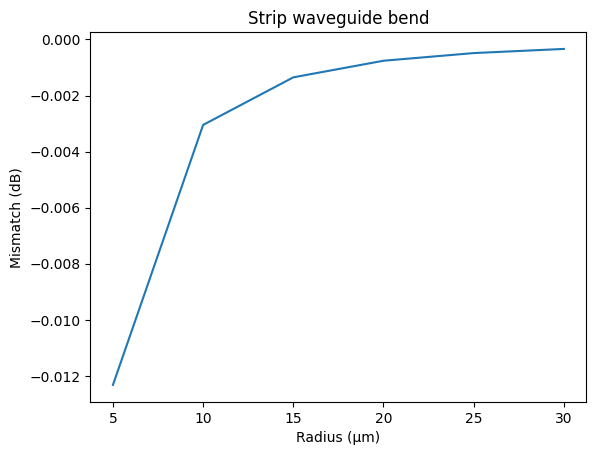

In [48]:
radii = np.arange(5,35,5)

mismatch = gt.modes.sweep_bend_mismatch(bend_1550_si, radii)

plt.plot(radii, 10 * np.log10(mismatch))
plt.xticks(radii)
plt.title("Strip waveguide bend")
plt.xlabel("Radius (μm)")
plt.ylabel("Mismatch (dB)")

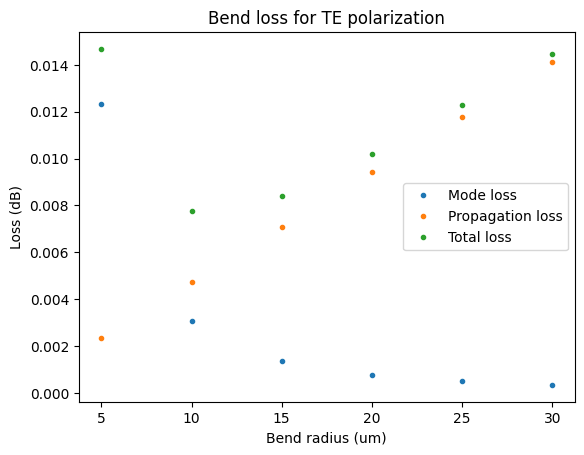

In [50]:
dB_cm = 3  # dB/cm Technology loss - 
length = 0.5 * np.pi * radii * 1e-6
propagation_loss = dB_cm * length * 1e2
propagation_loss

plt.title("Bend loss for TE polarization")
plt.plot(radii, -10 * np.log10(mismatch), ".", label="Mode loss")
plt.plot(radii, propagation_loss, ".", label="Propagation loss")
plt.plot(radii, propagation_loss-10 * np.log10(mismatch), ".", label="Total loss")
plt.xticks(radii)
plt.xlabel("Bend radius (um)")
plt.ylabel("Loss (dB)")
plt.legend()

2026-03-10 18:14:53.537 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_46e03244e15889f3.npz.


/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-10 18:14:56.303 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_0d14a8cbaabe2596.npz.


/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-10 18:14:59.361 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_90543171bd1acaef.npz.
2026-03-10 18:14:59.368 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_058c3027a1cc8643.npz.
2026-03-10 18:14:59.379 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_67060733974474ef.npz.


/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/lidia/cifoin-lab1/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.p

2026-03-10 18:15:00.202 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_818c117794f716e4.npz.
R =   5 um  ->  neff_TE0 = 3.060951
R =  10 um  ->  neff_TE0 = 3.015417
R =  15 um  ->  neff_TE0 = 3.005961
R =  20 um  ->  neff_TE0 = 3.002624
R =  25 um  ->  neff_TE0 = 3.001106
R =  30 um  ->  neff_TE0 = 3.000303


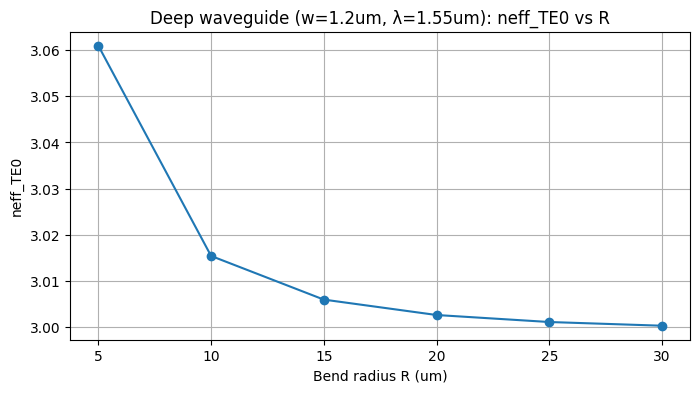

In [7]:
import numpy as np
import matplotlib.pyplot as plt

radii_si = np.arange(5, 35, 5)  # um
neff_TE0 = []

for R in radii_si:
    bend_1550_si = gt.modes.Waveguide(
        wavelength=1550 * nm,
        core_width=1.2,
        slab_thickness=0.0,       # DEEP
        core_material="si",
        clad_material="sio2",
        core_thickness=300 * nm,
        num_modes=1,
        cache_path=".cache/",
        precision="double",
        max_grid_scaling=1.2,
        grid_resolution=30,
        bend_radius=R,            # um
    )

    # --- FIX: n_eff a veces es escalar ---
    n_eff_val = np.asarray(bend_1550_si.n_eff).real
    neff0 = float(n_eff_val[0]) if n_eff_val.ndim > 0 else float(n_eff_val)
    neff_TE0.append(neff0)

neff_TE0 = np.array(neff_TE0)

for R, n in zip(radii_si, neff_TE0):
    print(f"R = {R:>3} um  ->  neff_TE0 = {n:.6f}")

plt.figure(figsize=(8,4))
plt.plot(radii_si, neff_TE0, marker="o")
plt.xticks(radii_si)
plt.xlabel("Bend radius R (um)")
plt.ylabel("neff_TE0")
plt.title("Deep waveguide (w=1.2um, λ=1.55um): neff_TE0 vs R")
plt.grid(True)
plt.show()

## Grading

LO.1. 1 Point <br> 
LO.2. 2 Points <br> 
LO.3. 1 Point <br> 
LO.4. 2 Points <br> 
LO.5. 1 Point <br> 
**Total 7 Points** <br>
Extra (Up to) 3 Points
